In [ ]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import compute_returns, moving_average, rolling_volatility, volume_ratio, trend_strength
from src.backtest import backtest, sharpe_ratio, volatility, max_drawdown
from src.strategy import momentum_trend_strategy, momentum_volatility_strategy, momentum_voluratio_strategy
from src.visualization import plot_performance

In [2]:
base_df = get_data('AAPL', '2021-01-01', '2026-01-01')
base_df = compute_returns(base_df)

[*********************100%***********************]  1 of 1 completed


# Features 

## Rolling Volatility

In [3]:
base_df = rolling_volatility(base_df)

/var/folders/f5/793n94tx3jj8c_rrt1drx2g40000gn/T/ipykernel_756/3506556160.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


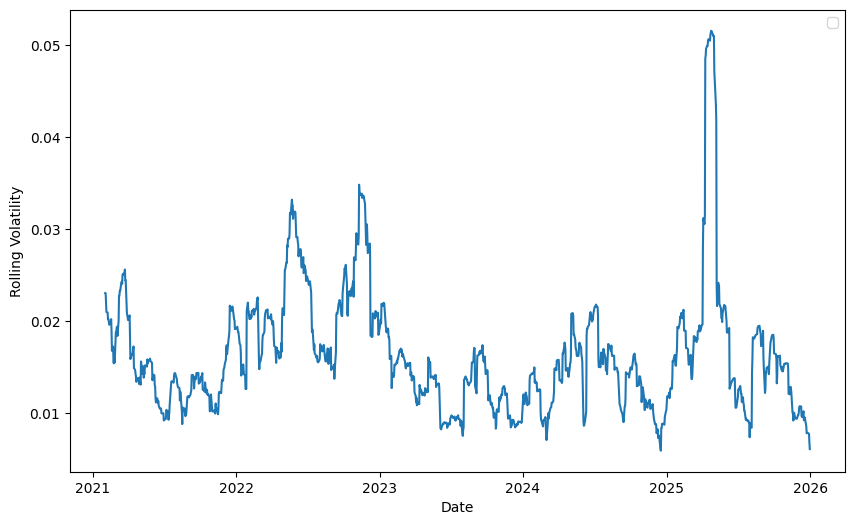

In [4]:
plt.figure(figsize=(10,6))
plt.plot(base_df.index, base_df["volatility"])

plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.legend()
plt.show()

## Volume Ratio

In [5]:
base_df = volume_ratio(base_df)

/var/folders/f5/793n94tx3jj8c_rrt1drx2g40000gn/T/ipykernel_756/3509842071.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


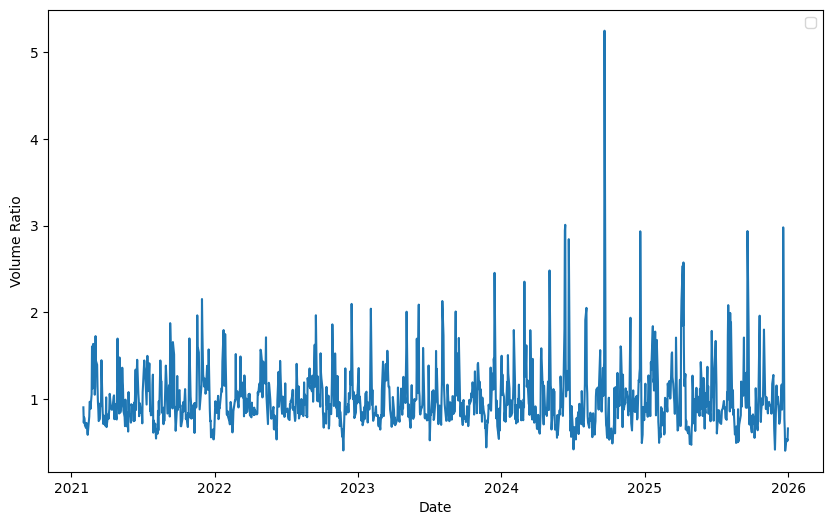

In [6]:
plt.figure(figsize=(10,6))
plt.plot(base_df.index, base_df["volume_ratio"])

plt.xlabel("Date")
plt.ylabel("Volume Ratio")
plt.legend()
plt.show()

## Trend Strength

In [7]:
base_df = trend_strength(base_df)

/var/folders/f5/793n94tx3jj8c_rrt1drx2g40000gn/T/ipykernel_756/2473690610.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


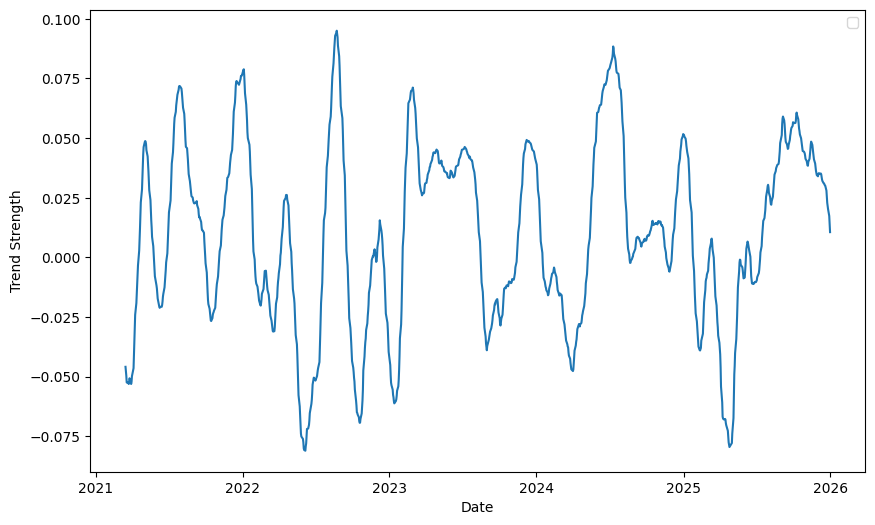

In [8]:
plt.figure(figsize=(10,6))
plt.plot(base_df.index, base_df["trend_strength"])

plt.xlabel("Date")
plt.ylabel("Trend Strength")
plt.legend()
plt.show()

# Filtered Strategies

## Momentum + Trend Strategy

In [9]:
df = base_df.copy()
df = momentum_trend_strategy(df)
df = backtest(df)

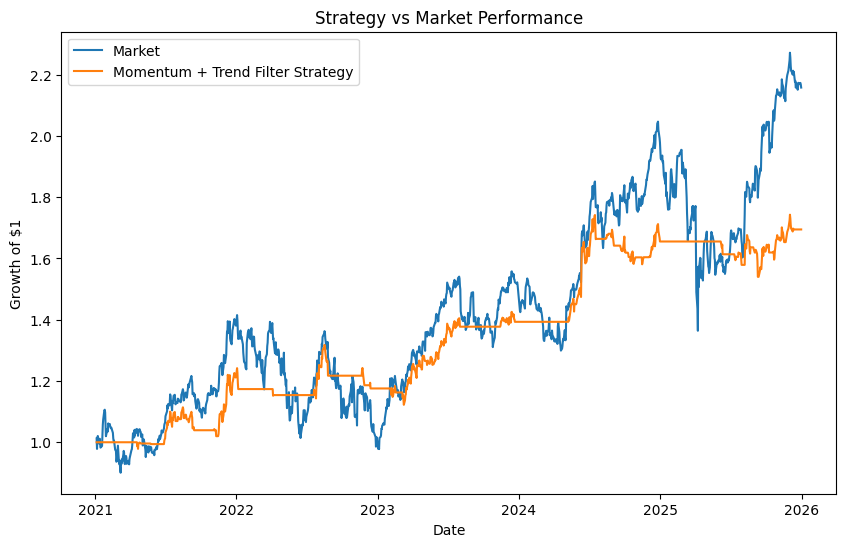

In [10]:
plot_performance(df)

## Momentum + Low Volatility Strategy

In [11]:
df = base_df.copy()
df = momentum_volatility_strategy(df)
df = backtest(df)

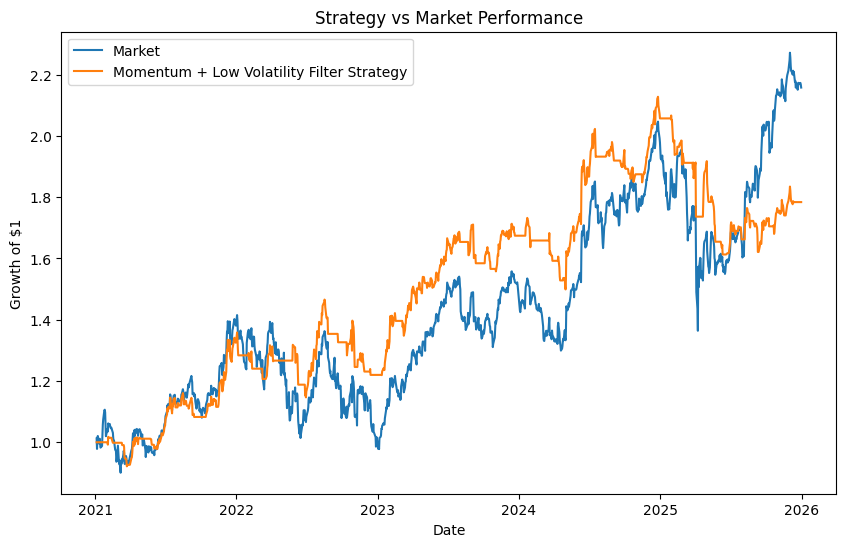

In [12]:
plot_performance(df)

## Momentum + Volume Ratio Strategy

In [13]:
df = base_df.copy()
df = momentum_voluratio_strategy(df)
df = backtest(df)

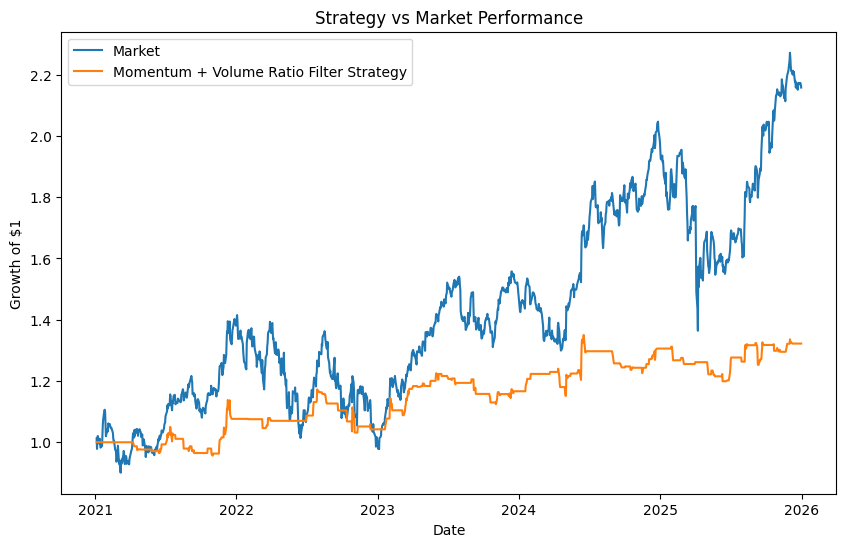

In [14]:
plot_performance(df)

# Parameter Testing

In [31]:
windows = [5, 10, 20, 50]
strategies = [
    ("Momentum + Trend Strength", momentum_trend_strategy, "mo_tr"),
    ("Momentum + Rolling Volatility", momentum_volatility_strategy, "mo_vo"),
    ("Momentum + Volume Ratio", momentum_voluratio_strategy, "mo_vr")
]

results = pd.DataFrame(columns=['Strategy', 'Window', 'Sharpe', 'Volatility', 'Max DD'])
row = 0

for name, strategy, ending in strategies:
    for w in windows:
        df = base_df.copy()
        df = strategy(df, window = w)
        returns , cumulative = "strategy_returns_" + ending, "cumulative_returns_" + ending

        df = backtest(df)
        strategy_sharpe = sharpe_ratio(df[returns])
        strategy_vol = volatility(df[returns])
        strategy_max_dd = max_drawdown(df[cumulative])

        results.loc[len(results)] = [name, w, strategy_sharpe, strategy_vol, strategy_max_dd]


results

,Strategy,Window,Sharpe,Volatility,Max DD
0,Momentum + Trend Strength,5,0.179097,0.124988,-0.252912
1,Momentum + Trend Strength,10,0.922157,0.123169,-0.148499
2,Momentum + Trend Strength,20,0.704734,0.145119,-0.221308
3,Momentum + Trend Strength,50,0.773787,0.161059,-0.173739
4,Momentum + Rolling Volatility,5,0.593479,0.177728,-0.182805
5,Momentum + Rolling Volatility,10,0.743093,0.177896,-0.241998
6,Momentum + Rolling Volatility,20,0.810275,0.176537,-0.212236
7,Momentum + Rolling Volatility,50,0.677115,0.179370,-0.243726
8,Momentum + Volume Ratio,5,0.589232,0.118050,-0.123590
9,Momentum + Volume Ratio,10,0.547491,0.114331,-0.120215
